# Gerando relatório EDA com Pandas Profiling

In [23]:
#Instalando e importando dependencias
#%pip install ydata-profiling
%matplotlib inline
from ydata_profiling import ProfileReport
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns  

In [24]:
df = pd.read_csv("..\\..\\data\\processed\\final_data.csv") 
df.head()

,Unnamed: 0,MATRICULA,VALOR_FATURA,VOLUME_FATURA_AGUA,VOLUME_FATURA_ESGOTO,VOLUME_MEDIDO_AGUA,VOLUME_MEDIDO_ESGOTO,DATA_VENCIMENTO,BAIRRO,ANO_VENCIMENTO,MES_VENCIMENTO,TRIMESTRE,VALOR_FATURA_lag1,VALOR_FATURA_lag2
0,0,706671,85.06,6.0,6.0,6.0,6.0,2022-04-18,BONFIM,2022,4,2,68.57,293.00
1,20539,21887161,10326.80,800.0,0.0,800.0,0.0,2022-04-18,SANTO AGOSTINHO,2022,4,2,9121.44,8951.45
2,20572,21887179,891.60,88.0,0.0,88.0,0.0,2022-04-18,SANTO AGOSTINHO,2022,4,2,809.15,832.37
3,20605,21949506,3034.67,162.0,162.0,162.0,162.0,2022-04-18,SAO GERALDO,2022,4,2,2193.68,1572.61
4,20638,21997306,18801.76,836.0,836.0,836.0,836.0,2022-04-18,AARAO REIS,2022,4,2,7917.38,7894.39


In [25]:
df.columns

Index(['Unnamed: 0', 'MATRICULA', 'VALOR_FATURA', 'VOLUME_FATURA_AGUA',
       'VOLUME_FATURA_ESGOTO', 'VOLUME_MEDIDO_AGUA', 'VOLUME_MEDIDO_ESGOTO',
       'DATA_VENCIMENTO', 'BAIRRO', 'ANO_VENCIMENTO', 'MES_VENCIMENTO',
       'TRIMESTRE', 'VALOR_FATURA_lag1', 'VALOR_FATURA_lag2'],
      dtype='object')

In [26]:
df.drop(columns='Unnamed: 0', inplace= True)
df['DATA_VENCIMENTO'] = pd.to_datetime(df['DATA_VENCIMENTO'])
df[['MATRICULA', 'BAIRRO', 'ANO_VENCIMENTO', 'MES_VENCIMENTO','TRIMESTRE']] = df[['MATRICULA', 'BAIRRO', 'ANO_VENCIMENTO', 'MES_VENCIMENTO','TRIMESTRE']].astype('category')

In [27]:
df.dtypes

MATRICULA                     category
VALOR_FATURA                   float64
VOLUME_FATURA_AGUA             float64
VOLUME_FATURA_ESGOTO           float64
VOLUME_MEDIDO_AGUA             float64
VOLUME_MEDIDO_ESGOTO           float64
DATA_VENCIMENTO         datetime64[ns]
BAIRRO                        category
ANO_VENCIMENTO                category
MES_VENCIMENTO                category
TRIMESTRE                     category
VALOR_FATURA_lag1              float64
VALOR_FATURA_lag2              float64
dtype: object

In [28]:
# Gerando relatório
profile = ProfileReport(df, title="Faturas de Agua")

In [29]:
profile.to_notebook_iframe()

Render HTML: 100%|██████████| 1/1 [00:02<00:00,  2.76s/it]


In [30]:
profile.to_file("EDA_final_data.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 43.27it/s]


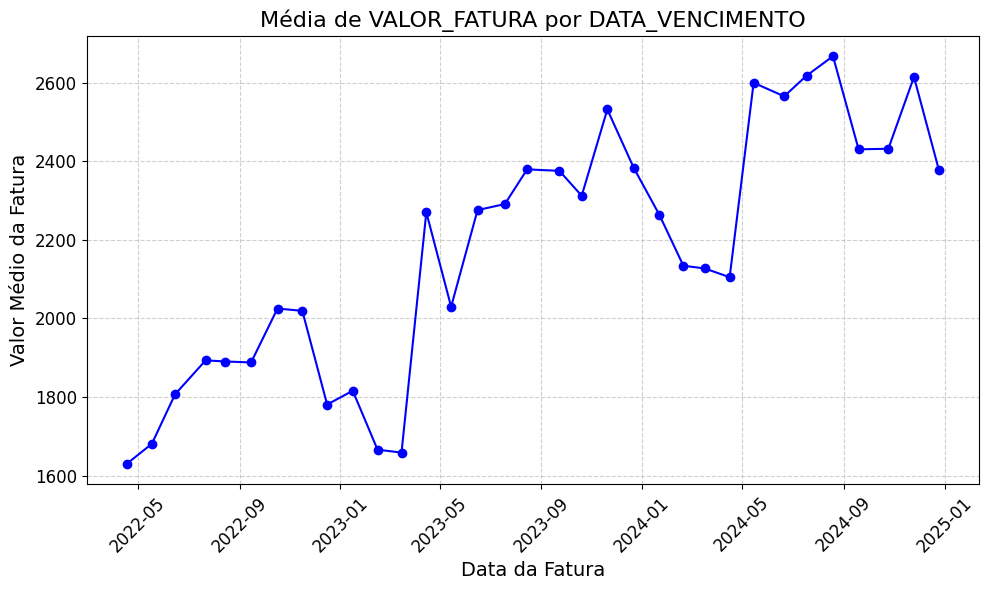

In [31]:
# Agrupar por DATA_VENCIMENTO e calcular a média de VALOR_FATURA
media_fatura = df.groupby('DATA_VENCIMENTO')['VALOR_FATURA'].mean().reset_index()

# Criar o gráfico de linhas
plt.figure(figsize=(10, 6))
plt.plot(media_fatura['DATA_VENCIMENTO'], media_fatura['VALOR_FATURA'], marker='o', linestyle='-', color='b')

# Personalizar o gráfico
plt.title('Média de VALOR_FATURA por DATA_VENCIMENTO', fontsize=16)
plt.xlabel('Data da Fatura', fontsize=14)
plt.ylabel('Valor Médio da Fatura', fontsize=14)
plt.grid(visible=True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# Exibir o gráfico
plt.tight_layout()
plt.show()

In [32]:
matricula_por_data = df.groupby('DATA_VENCIMENTO')['MATRICULA'].count().reset_index()
pd.DataFrame(matricula_por_data)
matricula_por_data

,DATA_VENCIMENTO,MATRICULA
0,2022-04-18,1734
1,2022-05-18,1747
2,2022-06-15,1753
3,2022-07-22,1765
4,2022-08-15,1770
5,2022-09-15,1775
6,2022-10-17,1783
7,2022-11-16,1788
8,2022-12-16,1797
9,2023-01-16,1800
